# GEARS - Notebook 3: Medium- and Long-Term Scenarios (GMM & VAE)

This notebook illustrates the full forecasting and EV charging demand simulation chain over extended horizons, from 1-3 year departmental forecasts to 5-20 year national trajectories, with hourly load profile reconstruction and smart charging optimisation - for both the GMM **and** the VAE.

**Section A - Medium Term (1-3 years)**
Daily energy demand forecasting per department with `DepartmentForecaster` (SARIMA) and fan charts.

**Section B - Long Term (5-20 years)**
Three EV adoption scenarios (conservative / central / ambitious) translated into daily energy trajectories with Monte-Carlo noise, built directly from the `gears.simulation.medium_term` functions (no longer duplicated by hand in this notebook).

**Section C - Load Profiles and Smart Charging (GMM + VAE)**
Reconstruction of the annual hourly profile from both the GMM **and** the VAE (`registry.load("french_vae_sample")`) with `OutputAggregator`, then comparison of plug-and-charge vs V1G with `SmartChargingOptimizer` for both models.

> **Execution notes:** the real `data/sample_df.pkl` file covers ~9.5 years (2016-2026) and 101
> departments (~2.7M sessions) - far more than this notebook needs. To stay within a budget of a
> few minutes: (a) `FOCUS_DEPTS` is reduced to 3 departments and the SARIMA training window to a
> recent window (`RECENT_MONTHS`); a single `.fit()` is reused for both the test window AND the
> forward-looking view (instead of a second full `.fit()` over the entire history); (b) Section C -
> normally **>30 minutes** because of the smart charging reconstruction over the full `"french"`
> bundle's 8008 contexts - is rebuilt on a restricted subset of contexts (2 location types x the
> focus departments), while keeping the full "plug" reconstruction (fast, ~20s) over the entire
> bundle so it stays representative.
> The real VAE registry key is `"french_vae_sample"` (not `"french_vae"`).
>
> **Session 6:** this version fixes two numerically-traced bugs (see REFACTOR_STATE.md /
> AUDIT.md §e) that produced an artificial "ceiling" in the long-term scenarios -- forecast
> noise (Section A) artificially pinched (`DepartmentForecaster` used 5% of the historical
> standard deviation instead of the full standard deviation), and a display clip at 10x the
> anchor (Section B) that visually flattened the central and ambitious scenarios well before the
> 2040 horizon. Section B has also been rebuilt to actually call the package's growth-profile
> functions (`linear_growth_profile`, `s_curve_growth_profile`, `bass_diffusion_profile`),
> fixed to start exactly at the currently observed level (t=0) and to have their saturation
> spread over the entire requested horizon rather than a fixed number of years. The number of
> exposed growth models is reduced from 5 to 3 (see REFACTOR_STATE.md for the justification of
> each removal).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os; os.makedirs("outputs", exist_ok=True)
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import gears
from gears import NativeSessionModelRegistry, load_sessions
from gears import CHARGER_PRESETS, OutputAggregator, LOCATION_POWER_PRESETS, SmartChargingOptimizer
from gears.data.insee import DepartmentForecaster, aggregate_by_department, build_panel
from gears.models.session_model import EVSessionModel
from gears.simulation.medium_term import (
    linear_growth_profile,
    s_curve_growth_profile,
    bass_diffusion_profile,
)
from gears.plotting import plot_mt_fan_charts, plot_lt_trajectories

In [2]:
# === CONFIGURATION ===

# Data
DATA_PATH     = "../data/sample_df.pkl"
FOCUS_DEPTS   = ["92", "69", "78"]   # reduced from 6 to 3 departments (execution budget)
RECENT_MONTHS = 14                  # history window for the departmental SARIMA

# Section A - Medium term
N_SCENARIOS      = 15    # reduced from 50 (execution budget)
TEST_DAYS        = 45    # reduced from 90 (test / hold-out window)
FORECAST_DAYS    = 60    # forecast days BEYOND the test window (reduced from 180)
COMBINED_HORIZON = TEST_DAYS + FORECAST_DAYS   # a single .fit() + a single .predict() cover both

# Section B - Long term
N_LONG_SCENARIOS = 10    # LT trajectories (the builder enforces a minimum of 30)
LONG_YEARS       = 15    # horizon 2025 -> 2040
NATIONAL_MONTHS  = 13    # window (all departments, full calendar months) for the national baseline

# Section C - Load profiles and smart charging
N_DAYS_MC_PROFILES = 8            # Monte-Carlo days (reduced from 20) for the "plug" profile (full bundle)
N_DAYS_MC_SMART    = 5             # Monte-Carlo days for the smart charging reconstruction (subset)
PROFILE_YEAR       = 2025          # reference year for the reconstruction
PROFILE_PRESET     = "french_2024" # key in LOCATION_POWER_PRESETS
SMART_LOC_TYPES    = {"work", "home"}   # subset of location types for Section C smart charging
SMART_DEPTS        = set(FOCUS_DEPTS)   # subset of departments for Section C smart charging

# French EV fleet constants (Avere-France, Q4 2024)
TOTAL_FLEET          = 38_500_000   # total passenger-vehicle fleet
EV_SHARE_NOW         = 0.031        # current electrification rate (~3.1%)
EV_VEHICLES_NOW      = int(TOTAL_FLEET * EV_SHARE_NOW)   # ~= 1.19M EVs
SESSIONS_PER_EV_DAY  = 0.22         # ~= 80 sessions/EV/year (IRVE data)

print(f"Total fleet : {TOTAL_FLEET:,} vehicles")
print(f"EV share    : {EV_SHARE_NOW:.1%}  ({EV_VEHICLES_NOW:,} EVs)")
print(f"Sessions/day: {EV_SHARE_NOW * TOTAL_FLEET * SESSIONS_PER_EV_DAY:,.0f}")

Total fleet : 38,500,000 vehicles
EV share    : 3.1%  (1,193,500 EVs)
Sessions/day: 262,570


---
# Part A — Medium Term (1–3 years)

Département-level daily energy demand forecasting with `DepartmentForecaster` (SARIMA per département).

In [3]:
# The real file covers 101 departments over ~9.5 years (~2.7M sessions, ~1.3 GB once
# validated). We filter on FOCUS_DEPTS *before* validation to limit memory and compute
# time, then restrict to a recent window (RECENT_MONTHS): SARIMA fits on very long series
# (years' worth) are both slow and memory-hungry for minimal gain in fidelity - recent
# charging behaviour is also more representative.
_raw = pd.read_pickle(DATA_PATH)
_dept_col = "insee_code_departement" if "insee_code_departement" in _raw.columns else "department"
_raw = _raw[_raw[_dept_col].astype(str).str.strip().isin(FOCUS_DEPTS)].copy()
df = load_sessions(_raw, verbose=True)
del _raw
gc.collect()

_cutoff = df["arrival_time"].max() - pd.DateOffset(months=RECENT_MONTHS)
df = df[df["arrival_time"] >= _cutoff].copy()

print(f"\nDate range (recent window): {df['arrival_time'].min().date()} -> {df['arrival_time'].max().date()}")
print(f"Departments: {df['department'].nunique()}  ({sorted(df['department'].unique())})")

[GEARS] Loaded 457,066 sessions.
[GEARS] Departments: 3
[GEARS] Location types: {'public': np.int64(230437), 'work': np.int64(159409), 'home': np.int64(64708), 'heavy': np.int64(2512)}
             count       mean        std       min   25%     50%       75%         max  missing_%
duration  457066.0   4.069831   6.420194  0.033333  0.90   2.325   5.13025  167.821667        0.0
energy    457066.0  18.711039  17.182504  0.500000  7.42  13.020  26.22975  393.940000        0.0



Date range (recent window): 2024-12-28 -> 2026-02-28
Departments: 3  (['69', '78', '92'])


Panel shape : 428 days x 3 departments
Date range  : 2024-12-28 -> 2026-02-28
Focus departments available: ['92', '69', '78']


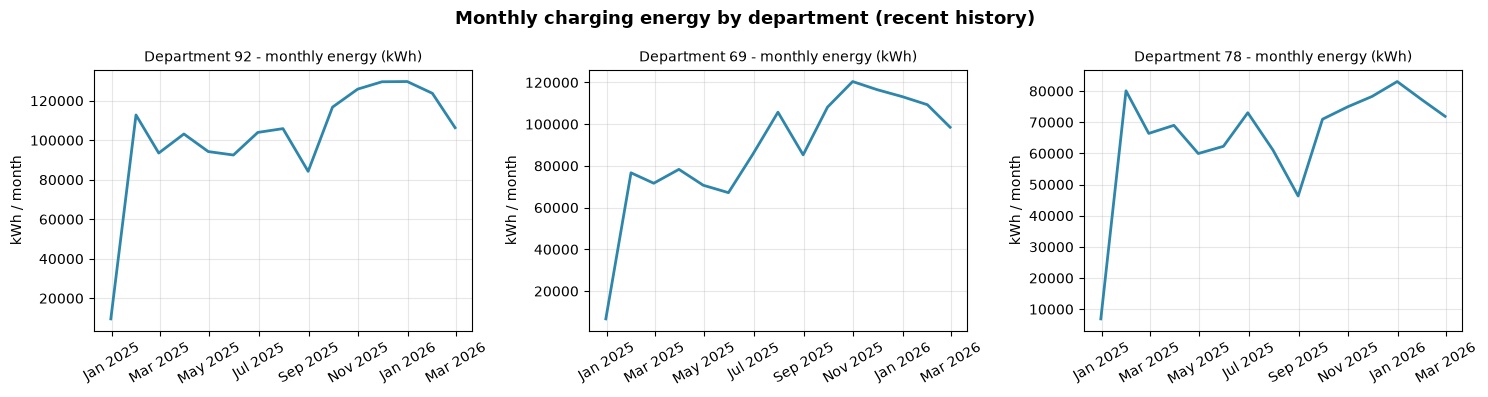

In [4]:
# Builds the DatetimeIndex x department-column panel, then a monthly overview.
panel = build_panel(df, freq="D", metric="energy_kwh")
panel.index = pd.to_datetime(panel.index)   # ensures a clean DatetimeIndex
print(f"Panel shape : {panel.shape[0]} days x {panel.shape[1]} departments")
print(f"Date range  : {panel.index.min().date()} -> {panel.index.max().date()}")
print(f"Focus departments available: {[d for d in FOCUS_DEPTS if d in panel.columns]}")

agg_monthly = aggregate_by_department(df, freq="ME", metric="energy_kwh")
agg_monthly["date"] = pd.to_datetime(agg_monthly["date"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, dept in zip(np.atleast_1d(axes).flat, FOCUS_DEPTS):
    sub = agg_monthly[agg_monthly["department"] == dept].sort_values("date") \
        if "department" in agg_monthly.columns else None
    if sub is None or sub.empty:
        ax.set_visible(False); continue
    ax.plot(sub["date"].values, sub["energy_kwh"].values, color="#2E86AB", linewidth=2)
    ax.set_title(f"Department {dept} - monthly energy (kWh)", fontsize=10)
    ax.set_ylabel("kWh / month"); ax.set_xlabel("")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Monthly charging energy by department (recent history)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/03_monthly_energy_by_dept.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Train / test split, then fit DepartmentForecaster (SARIMA per department).
split_date  = panel.index.max() - pd.Timedelta(days=TEST_DAYS)
panel_train = panel[panel.index <= split_date]
panel_test  = panel[panel.index >  split_date]

train_df = df[df["arrival_time"] <= split_date].copy()
test_df  = df[df["arrival_time"] >  split_date].copy()

print(f"Train: {panel_train.index.min().date()} -> {panel_train.index.max().date()}  ({len(panel_train)} days)")
print(f"Test : {panel_test.index.min().date()} -> {panel_test.index.max().date()}  ({len(panel_test)} days)")

fc = DepartmentForecaster(
    seasonal_period=7, max_p=2, max_q=2, max_P=1, max_Q=1,
    min_obs=60, use_log=True,
)
fc.fit(train_df, departments=FOCUS_DEPTS, verbose=True)

Train: 2024-12-28 -> 2026-01-14  (383 days)
Test : 2026-01-15 -> 2026-02-28  (45 days)


[GEARS] DepartmentForecaster fitted: 3/3 departments with SARIMA, 0 using mean fallback.


DepartmentForecaster(n_departments=3, n_fitted_sarima=3, seasonal_period=7)

In [6]:
# A single .predict() over COMBINED_HORIZON covers both the test window (evaluated against
# the ground truth) and the forward-looking view beyond it (reused as-is further below, no
# second full .fit() over the entire history).
full_fc = fc.predict(
    horizon=COMBINED_HORIZON,
    departments=FOCUS_DEPTS,
    n_scenarios=N_SCENARIOS,
    start_date=panel_test.index.min(),
    seed=0,
)
full_fc["date"] = pd.to_datetime(full_fc["date"])

test_end   = panel_test.index.min() + pd.Timedelta(days=TEST_DAYS)
test_fc    = full_fc[full_fc["date"] < test_end].copy()
forward_fc = full_fc   # forward-looking view: reuses the same fit + the same predict as above

rows = []
for dept in FOCUS_DEPTS:
    if dept not in panel_test.columns: continue
    actual = panel_test[dept].fillna(0)
    pred_dept = test_fc[test_fc["department"] == dept]
    if pred_dept.empty: continue
    pred_median = (
        pred_dept.groupby("date")["energy_kwh_forecast"]
        .median()
        .reindex(actual.index, fill_value=0)
    )
    mae  = float(np.abs(pred_median - actual).mean())
    rmse = float(np.sqrt(((pred_median - actual)**2).mean()))
    nz   = actual > 0
    mape = float(np.abs((pred_median[nz] - actual[nz]) / actual[nz]).mean()) * 100
    rows.append({"Département": dept, "MAE (kWh)": round(mae, 0),
                 "RMSE (kWh)": round(rmse, 0), "MAPE (%)": round(mape, 1)})

metrics_df = pd.DataFrame(rows)
print("-- Medium-term evaluation metrics --------------------------------")
print(metrics_df.to_string(index=False))
print(f"\nForward-looking view: {COMBINED_HORIZON} days total for {len(FOCUS_DEPTS)} departments "
      f"(of which the first {TEST_DAYS} days are evaluated above against the ground truth)")

-- Medium-term evaluation metrics --------------------------------
Département  MAE (kWh)  RMSE (kWh)  MAPE (%)
         92     3556.0      3631.0      91.1
         69      947.0      1154.0      27.9
         78      641.0       822.0      27.4

Forward-looking view: 105 days total for 3 departments (of which the first 45 days are evaluated above against the ground truth)


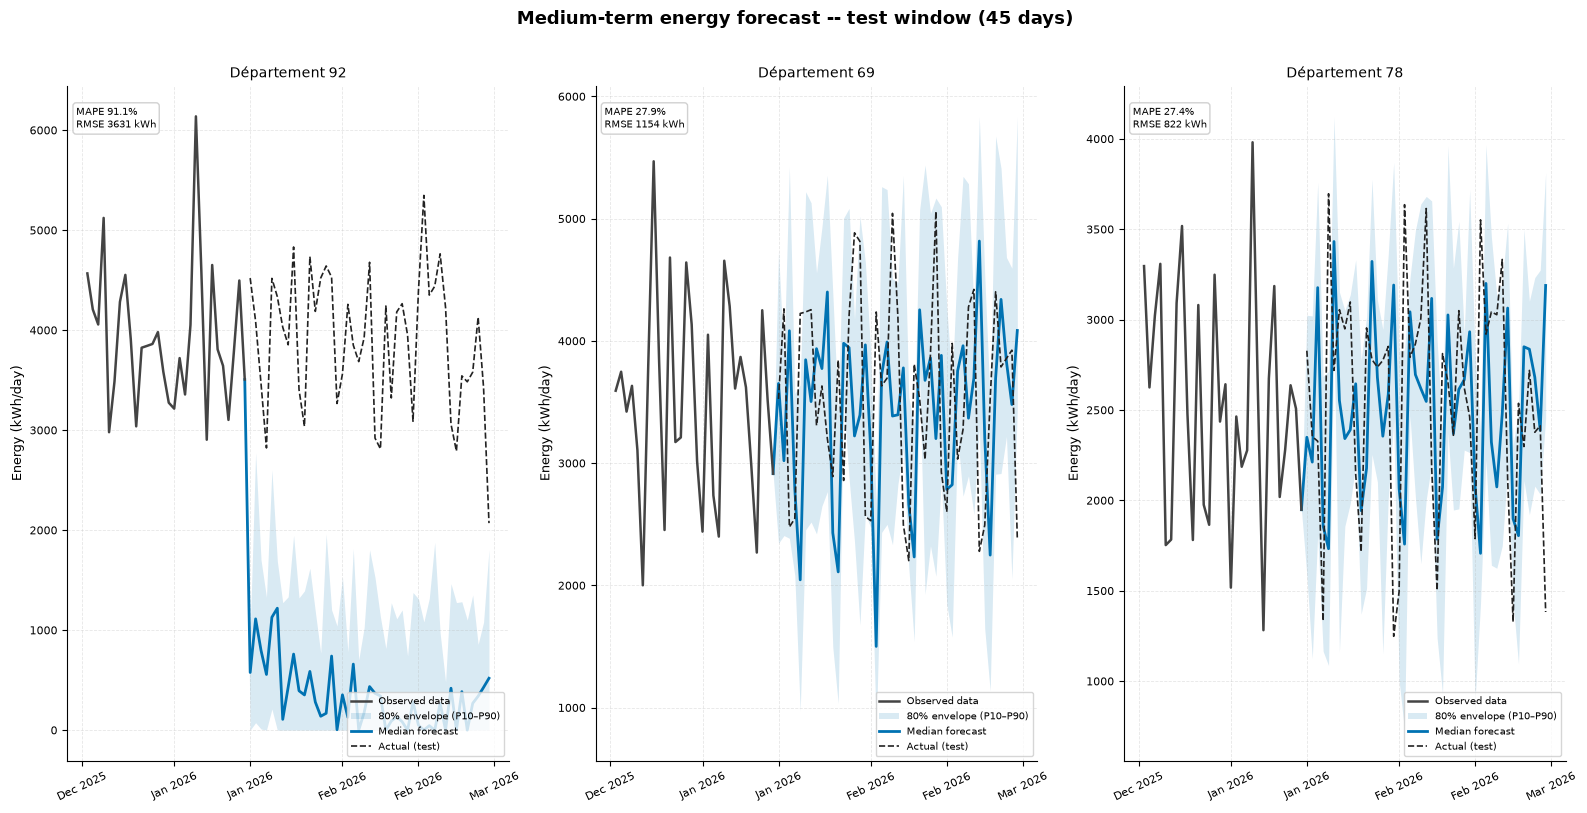

Mean width of the 80% band (measured): 170.4% of the median (before Session 6, ~2% expected -- see AUDIT.md Mechanism 1)


In [7]:
# Session 6: DepartmentForecaster._forecast_dept now uses the full standard deviation
# (not 5%) as the noise scale -- see gears/data/insee.py and REFACTOR_STATE.md. The
# confidence band below should be clearly visible, not a near-flat line.
fig_mt = plot_mt_fan_charts(
    panel=panel_train,
    forecast_df=test_fc,
    departments=FOCUS_DEPTS,
    hist_tail_days=30,
    metrics_df=metrics_df,
    n_cols=3,
    figsize=(16, 8),
    title=f"Medium-term energy forecast -- test window ({TEST_DAYS} days)",
    savepath="outputs/03_medium_fan_charts.png",
)

# Overlay the actual values on the test-period fan charts
axes_flat = np.array(fig_mt.axes).flatten()
for ax, dept in zip(axes_flat, FOCUS_DEPTS):
    if dept not in panel_test.columns:
        continue
    actual = panel_test[dept].fillna(0)
    ax.plot(
        actual.index, actual.values,
        color="#222222", linewidth=1.2, linestyle="--", zorder=5,
        label="Actual (test)",
    )
    ax.legend(fontsize=7, loc="lower right")

fig_mt.savefig("outputs/03_medium_fan_charts.png", dpi=150, bbox_inches="tight")
plt.show()

# Measured width of the 80% band (useful to confirm the noise fix above, not just
# assert it):
pivot_check = test_fc.pivot_table(index="date", columns=["department", "scenario"],
                                   values="energy_kwh_forecast")
med_check = pivot_check.median(axis=1)
width_check = pivot_check.quantile(0.9, axis=1) - pivot_check.quantile(0.1, axis=1)
rel_width_check = float((width_check / med_check.clip(lower=1e-6)).mean())
print(f"Mean width of the 80% band (measured): {rel_width_check:.1%} of the median "
      f"(before Session 6, ~2% expected -- see AUDIT.md Mechanism 1)")

---
# Part B — Long Term (5–20 years)

### EV market adoption curves → energy implications

**Approach**
1. Define three EV fleet adoption scenarios, built from the (Session 6-fixed)
   `linear_growth_profile` / `s_curve_growth_profile` / `bass_diffusion_profile`
   functions in `gears.simulation.medium_term` — each anchored exactly at
   today's observed fleet share at t=0, not zero.
2. Plot adoption curves and their derivative (annual new EVs added).
3. Scale the current national baseline energy by each scenario's adoption
   multiplier, with Monte-Carlo noise calibrated on real historical
   volatility, to get daily-energy trajectories.
4. Analyse grid capacity implications.

**Sources:** Avere-France, SNEF, Observatoire du Véhicule d'Entreprise (2024),
EU Green Deal 2035 target, French PNEC 2030 objectives.

In [8]:
# Session 6: these three scenarios are now built by actually calling the
# gears.simulation.medium_term functions (instead of duplicating their formulas by hand).
# Each function is called with base_sessions_per_day=1.0: its output IS directly the
# "multiple of the current rate" trajectory, since the three profiles now guarantee
# growth(t=0) == 1.0 exactly (fixed in Session 6 -- see REFACTOR_STATE.md).
# Only adoption_mul.values is used (not adoption_mul.index): the real temporal
# calibration (sim_start_date) is only known once panel_nat is loaded further below.
START_YEAR = 2025
END_YEAR   = START_YEAR + LONG_YEARS

conservative_mul = linear_growth_profile(
    1.0, LONG_YEARS, annual_growth_rate=(0.20 / EV_SHARE_NOW - 1) / LONG_YEARS,
)
central_mul = s_curve_growth_profile(
    1.0, LONG_YEARS, saturation_factor=0.40 / EV_SHARE_NOW,
)
ambitious_mul = bass_diffusion_profile(
    1.0, LONG_YEARS, market_potential_factor=0.65 / EV_SHARE_NOW, p=0.03, q=0.38,
)

scenarios = {
    "Conservative (linear)": ("A", conservative_mul, "#9B5DE5", "-"),
    "Central (s-curve)":     ("B", central_mul,      "#2E86AB", "--"),
    "Ambitious (bass)":      ("C", ambitious_mul,    "#E84855", "-."),
}

print(f"Scenarios defined -- starting from {EV_SHARE_NOW:.1%} EV share ({EV_VEHICLES_NOW:,} vehicles)")
print(f"{'Year':>6}  {'Conservative':>14}  {'Central':>12}  {'Ambitious':>12}")
for yr_offset in [0, 2, 5, 8, 12, 15]:
    idx = min(int(yr_offset * 365.25), len(conservative_mul) - 1)
    row = [f"{START_YEAR + yr_offset:>6}"]
    for name, (_, mul, _, _) in scenarios.items():
        share = EV_SHARE_NOW * mul.iloc[idx]
        row.append(f"{share:.1%}".rjust(14 if "Conservative" in name else 12))
    print("  ".join(row))

print(f"\nGrowth factor {START_YEAR}->{END_YEAR} (share / energy-proportional; measured, not assumed):")
for name, (lbl, mul, _, _) in scenarios.items():
    factor = float(mul.iloc[-1] / mul.iloc[0])
    print(f"  {name:24s}: {factor:5.1f}x")

Scenarios defined -- starting from 3.1% EV share (1,193,500 vehicles)
  Year    Conservative       Central     Ambitious
  2025            3.1%          3.1%          3.1%
  2027            5.4%          5.1%          8.4%
  2030            8.7%         11.7%         23.6%
  2033           12.1%         22.6%         43.4%
  2037           16.6%         34.5%         59.3%
  2040           20.0%         38.2%         63.2%

Growth factor 2025->2040 (share / energy-proportional; measured, not assumed):
  Conservative (linear)   :   6.5x
  Central (s-curve)       :  12.3x
  Ambitious (bass)        :  20.4x


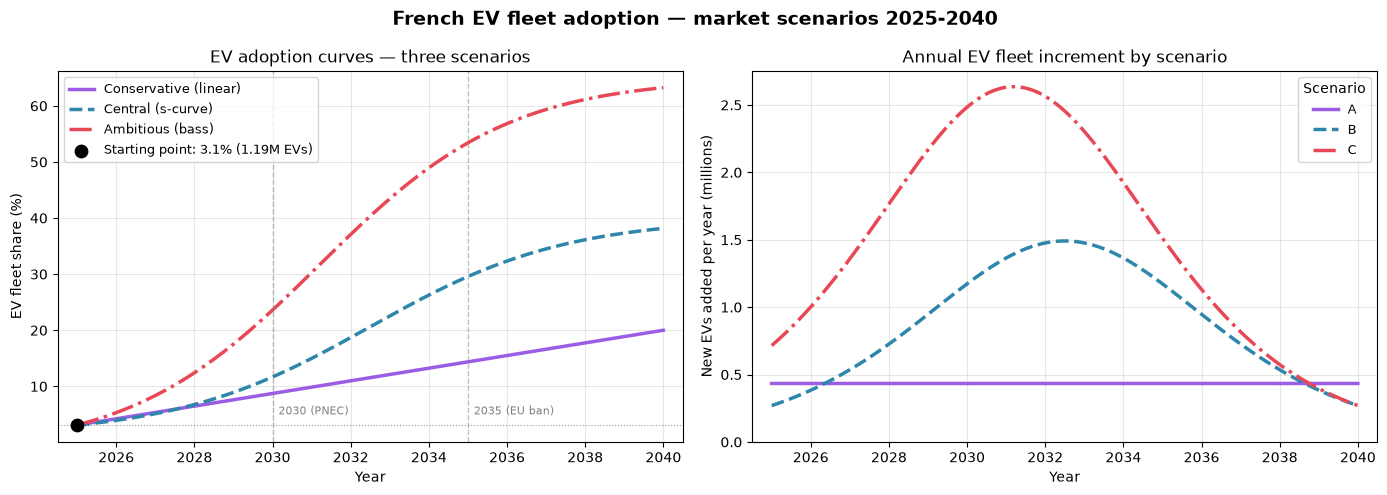

In [9]:
years_numeric = START_YEAR + np.arange(len(conservative_mul)) / 365.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, (lbl, mul, color, ls) in scenarios.items():
    ax.plot(years_numeric, EV_SHARE_NOW * mul.values * 100, color=color, linestyle=ls,
            linewidth=2.5, label=name)
ax.scatter([START_YEAR], [EV_SHARE_NOW * 100], color="black", s=80, zorder=6,
           label=f"Starting point: {EV_SHARE_NOW:.1%} ({EV_VEHICLES_NOW/1e6:.2f}M EVs)")
ax.axhline(EV_SHARE_NOW * 100, color="black", linewidth=0.8, linestyle=":", alpha=0.4)
for yr, label in [(2030, "2030 (PNEC)"), (2035, "2035 (EU ban)")]:
    ax.axvline(yr, color="gray", linewidth=1, linestyle="--", alpha=0.5)
    ax.text(yr + 0.15, 5, label, fontsize=8, color="gray")
ax.set_xlabel("Year"); ax.set_ylabel("EV fleet share (%)")
ax.set_title("EV adoption curves — three scenarios", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)

ax2 = axes[1]
for name, (lbl, mul, color, ls) in scenarios.items():
    share = EV_SHARE_NOW * mul.values
    d_share = np.gradient(share, years_numeric)
    new_evs_M = d_share * TOTAL_FLEET / 1e6
    ax2.plot(years_numeric, new_evs_M, color=color, linestyle=ls, linewidth=2.5, label=lbl)
ax2.set_xlabel("Year"); ax2.set_ylabel("New EVs added per year (millions)")
ax2.set_title("Annual EV fleet increment by scenario", fontsize=12)
ax2.legend(fontsize=9, title="Scenario"); ax2.grid(True, alpha=0.3)
ax2.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5); ax2.set_ylim(bottom=0)

fig.suptitle("French EV fleet adoption — market scenarios 2025-2040", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/03_adoption_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Lightweight national panel (all departments, recent window aligned on full calendar
# months): used (a) as the energy baseline below and (b) as historical context in the
# trajectories chart further down. Loaded once here (dropped at the end of Part B) rather
# than keeping the full dataset (101 departments, ~9.5 years) in memory the whole time.
_raw_nat  = pd.read_pickle(DATA_PATH)
_dept_col = "insee_code_departement" if "insee_code_departement" in _raw_nat.columns else "department"
_ts_col   = "debut_session_timestamp" if "debut_session_timestamp" in _raw_nat.columns else "arrival_time"
_max_ts   = pd.to_datetime(_raw_nat[_ts_col], format="mixed", errors="coerce").max()
_last_full_month_end = _max_ts.to_period("M").to_timestamp() - pd.Timedelta(days=1)
_cutoff_nat = (_last_full_month_end - pd.DateOffset(months=NATIONAL_MONTHS)).replace(day=1)
_ts_all = pd.to_datetime(_raw_nat[_ts_col], format="mixed", errors="coerce")
_raw_nat = _raw_nat[(_ts_all >= _cutoff_nat) & (_ts_all <= _last_full_month_end)].copy()

df_nat = load_sessions(_raw_nat, verbose=False)
del _raw_nat, _ts_all
gc.collect()

panel_nat = build_panel(df_nat, freq="D", metric="energy_kwh")
panel_nat.index = pd.to_datetime(panel_nat.index)
print(f"National panel (all departments): {panel_nat.shape[1]} departments, "
      f"{panel_nat.index.min().date()} -> {panel_nat.index.max().date()}  "
      f"({NATIONAL_MONTHS} full calendar months)")
del df_nat
gc.collect()

last30 = panel_nat.tail(30)
baseline_energy_kwh = float(last30.sum(axis=1).mean())
print(f"Energy baseline (last 30-day mean, {panel_nat.shape[1]} departments): {baseline_energy_kwh:,.0f} kWh/day")

sim_start_date = panel.index.max() + pd.Timedelta(days=1)
print(f"Simulation start date: {sim_start_date.date()}")

hist_monthly_nat = panel_nat.sum(axis=1).resample("ME").mean()
monthly_returns  = hist_monthly_nat.pct_change().dropna()
historical_cv    = float(monthly_returns.std())
print(f"Historical monthly CV : {historical_cv:.3f}  (sigma of the per-scenario log-normal noise)")

def build_lt_scenario_analytical(baseline_kwh, adoption_mul_values, sim_start, n_scenarios, cv, seed):
    '''
    Builds LT trajectories via analytical scaling of the adoption curve -- itself coming
    from the gears.simulation.medium_term functions (Session 6), not duplicated by hand:
    energy(t, sc) = baseline * adoption_mul(t) * eps(t, sc), where eps ~ LogNormal(0, cv) is
    monthly multiplicative noise, accumulated as a smoothed (autocorrelated) random walk for
    visually coherent trajectories.
    Analytical rather than session-by-session GMM simulation: at national scale (up to
    several million sessions/day by the end of the horizon for the central/ambitious
    scenarios), simulating each session individually over 15 years x 30 scenarios would be
    numerically intractable within this notebook's budget (see REFACTOR_STATE.md, Session 6,
    for the timing measurement that motivated this choice -- MediumTermSimulator remains
    suited to more modest horizons/scales, not this multi-decade national use case).
    '''
    rng = np.random.default_rng(seed)
    dates = pd.date_range(sim_start, periods=len(adoption_mul_values), freq="D")
    n_months = int(np.ceil(len(adoption_mul_values) / 30.44)) + 1
    rows = []
    for sc in range(n_scenarios):
        monthly_eps = np.exp(np.cumsum(rng.normal(0, cv / np.sqrt(12), n_months)))
        monthly_eps = monthly_eps / monthly_eps[0]
        month_idx = np.minimum((np.arange(len(dates)) / 30.44).astype(int), n_months - 1)
        energy = baseline_kwh * adoption_mul_values * monthly_eps[month_idx]
        rows.append(pd.DataFrame({
            "date": dates, "scenario": sc,
            "n_sessions": np.maximum(0, energy / 22).astype(int),
            "total_energy_kwh": np.maximum(0.0, energy),
        }))
    return pd.concat(rows, ignore_index=True)

N_LONG_SCENARIOS_ACTUAL = max(N_LONG_SCENARIOS, 30)
trajectory_results = {}
for name, (lbl, mul, color, ls) in scenarios.items():
    result = build_lt_scenario_analytical(
        baseline_kwh=baseline_energy_kwh, adoption_mul_values=mul.values, sim_start=sim_start_date,
        n_scenarios=N_LONG_SCENARIOS_ACTUAL, cv=historical_cv, seed=hash(lbl) % (2**31),
    )
    day1 = float(result[result["date"] == result["date"].min()]["total_energy_kwh"].mean())
    last_day = float(result[result["date"] == result["date"].max()]["total_energy_kwh"].mean())
    print(f"  {lbl}: day-1={day1:,.0f} kWh (baseline={baseline_energy_kwh:,.0f}) | "
          f"ratio_t0={day1/baseline_energy_kwh:.2f} | final={last_day/1e3:,.0f} MWh/day "
          f"(growth factor {last_day/day1:.1f}x)")
    trajectory_results[name] = {"result": result, "color": color, "ls": ls}

National panel (all departments): 101 departments, 2024-12-01 -> 2026-01-31  (13 full calendar months)


Energy baseline (last 30-day mean, 101 departments): 51,374 kWh/day
Simulation start date: 2026-03-01
Historical monthly CV : 0.074  (sigma of the per-scenario log-normal noise)
  A: day-1=51,374 kWh (baseline=51,374) | ratio_t0=1.00 | final=360 MWh/day (growth factor 7.0x)
  B: day-1=51,374 kWh (baseline=51,374) | ratio_t0=1.00 | final=598 MWh/day (growth factor 11.6x)
  C: day-1=51,374 kWh (baseline=51,374) | ratio_t0=1.00 | final=1,035 MWh/day (growth factor 20.1x)


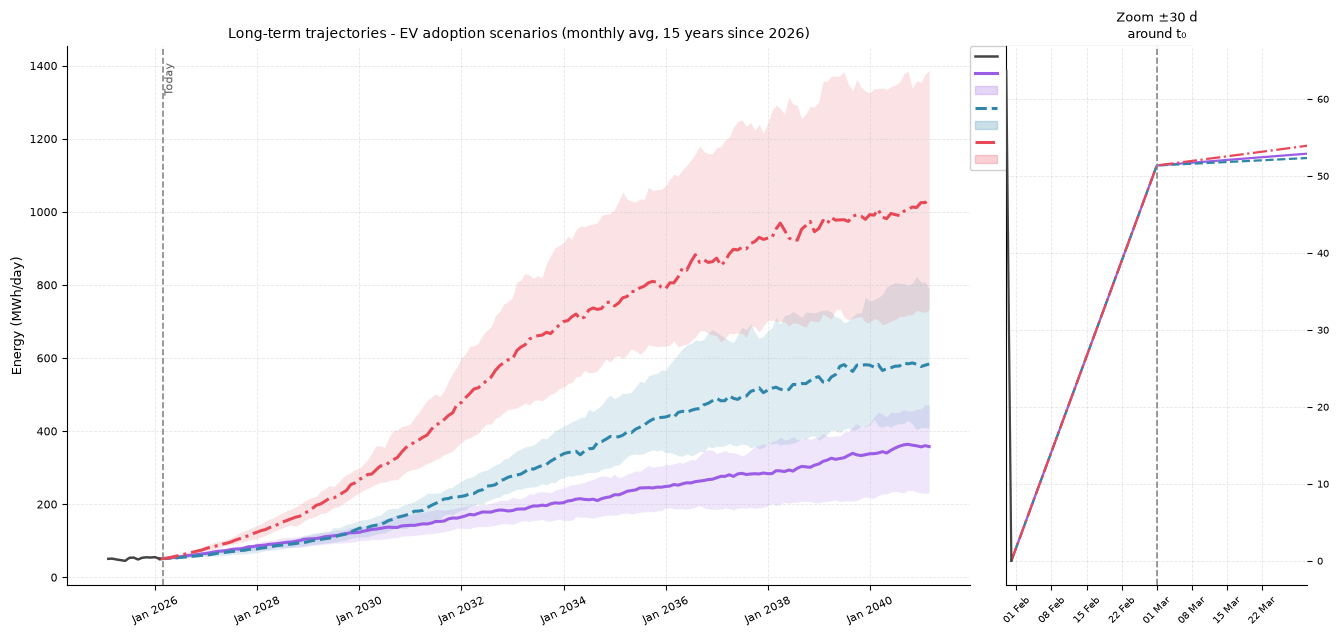

71

In [11]:
# Session 6: plot_lt_trajectories no longer applies an artificial clip at 10x the anchor --
# see gears/plotting.py and REFACTOR_STATE.md (AUDIT.md Mechanism 2). The central and
# ambitious scenarios below should now keep growing visibly all the way to the horizon,
# with no flattening before 2040.
fig_lt = plot_lt_trajectories(
    panel=panel_nat,
    trajectory_results=trajectory_results,
    sim_start_date=sim_start_date,
    hist_tail_months=min(18, NATIONAL_MONTHS),
    zoom_days=30,
    energy_col="total_energy_kwh",
    figsize=(16, 7),
    title=f"Long-term trajectories - EV adoption scenarios (monthly avg, {LONG_YEARS} years since {sim_start_date.year})",
    savepath="outputs/03_lt_trajectories.png",
)
plt.show()

del panel_nat
gc.collect()

-- Grid capacity implications ------------------------------------------------
  Conservative (linear)         0.05 GWh ->     0.33 GWh  (  6.5x)
  Central (s-curve)             0.05 GWh ->     0.63 GWh  ( 12.3x)
  Ambitious (bass)              0.05 GWh ->     1.05 GWh  ( 20.4x)

Scenario  Growth factor  Sessions end  Energy 2040 (GWh/day)
       A            6.5       1693804                   0.33
       B           12.3       3232272                   0.63
       C           20.4       5356529                   1.05


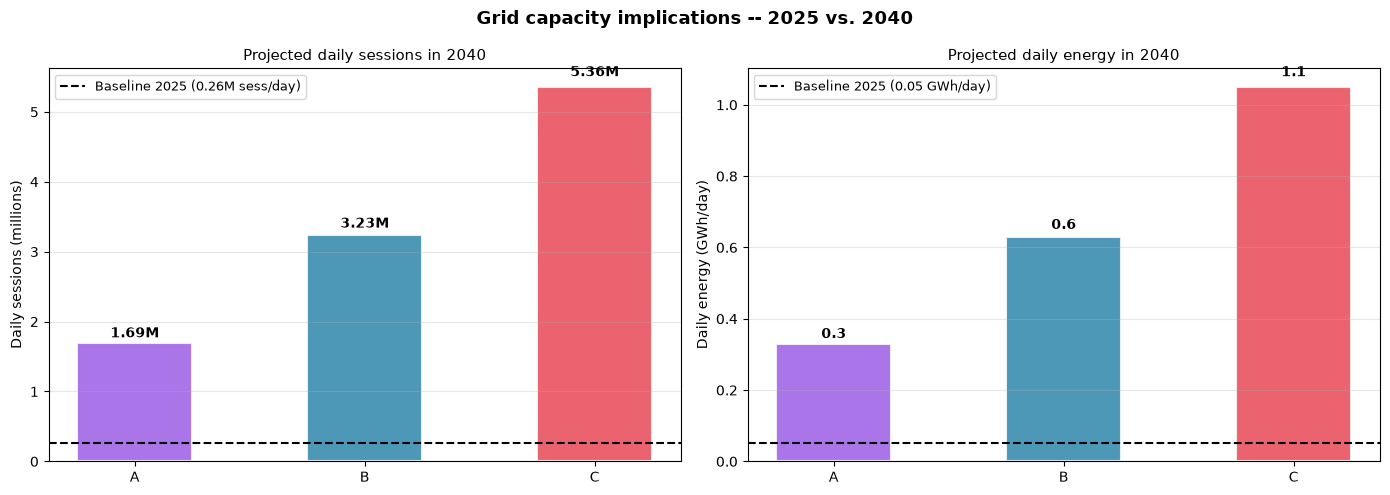

In [12]:
# Grid capacity implications, derived directly from each scenario's (fixed) multiplier.
print("-- Grid capacity implications ------------------------------------------------")
base_sessions = EV_VEHICLES_NOW * SESSIONS_PER_EV_DAY
rows_cap = []
for name, (lbl, mul, color, ls) in scenarios.items():
    factor = float(mul.iloc[-1] / mul.iloc[0])
    sess_end = EV_SHARE_NOW * float(mul.iloc[-1]) * TOTAL_FLEET * SESSIONS_PER_EV_DAY
    e_start_gwh = baseline_energy_kwh * 1e-6
    e_end_gwh   = baseline_energy_kwh * factor * 1e-6
    print(f"  {name:24s}  {e_start_gwh:>8.2f} GWh -> {e_end_gwh:>8.2f} GWh  ({factor:>5.1f}x)")
    rows_cap.append({"Scenario": lbl, "Growth factor": round(factor, 1),
                     "Sessions end": int(sess_end),
                     f"Energy {END_YEAR} (GWh/day)": round(e_end_gwh, 2)})
cap_df = pd.DataFrame(rows_cap)
print()
print(cap_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scen_labels  = [lbl for _, (lbl, _, _, _) in scenarios.items()]
colors_list  = [color for _, (_, _, color, _) in scenarios.items()]

ax = axes[0]
sessions_end = [row["Sessions end"] for row in rows_cap]
bars = ax.bar(scen_labels, [s/1e6 for s in sessions_end], color=colors_list,
              alpha=0.85, edgecolor="white", linewidth=1.5, width=0.5)
ax.axhline(base_sessions/1e6, color="black", linewidth=1.5, linestyle="--",
           label=f"Baseline {START_YEAR} ({base_sessions/1e6:.2f}M sess/day)")
for bar, v in zip(bars, sessions_end):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f"{v/1e6:.2f}M", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Daily sessions (millions)")
ax.set_title(f"Projected daily sessions in {END_YEAR}", fontsize=11)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

ax2 = axes[1]
e_end = [row[f"Energy {END_YEAR} (GWh/day)"] for row in rows_cap]
bars2 = ax2.bar(scen_labels, e_end, color=colors_list,
                alpha=0.85, edgecolor="white", linewidth=1.5, width=0.5)
ax2.axhline(baseline_energy_kwh/1e6, color="black", linewidth=1.5, linestyle="--",
            label=f"Baseline {START_YEAR} ({baseline_energy_kwh/1e6:.2f} GWh/day)")
for bar, v in zip(bars2, e_end):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
             f"{v:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylabel("Daily energy (GWh/day)")
ax2.set_title(f"Projected daily energy in {END_YEAR}", fontsize=11)
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=0.3)

fig.suptitle(f"Grid capacity implications -- {START_YEAR} vs. {END_YEAR}", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/03_capacity_2040.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Section C — Load Profile Reconstruction with Smart Charging

This section uses `OutputAggregator.build_load_profiles()` to reconstruct an annual hourly load profile from the French GMM, then compares **plug-and-charge** behaviour (immediate charging on arrival) with **smart charging V1G** (deferring charging to lower-cost hours), via `SmartChargingOptimizer`.

The price signal used below is **synthetic** (daily sinusoid + noise): it illustrates the method without requiring a real price file. Replace `price_signal` with a series from EPEX Spot or the grid operator for an operational analysis.

GMM  'french'            : 8008 contexts
VAE  'french_vae_sample' : 516 contexts (bundle sample, is_sample_=False)



-- Annual plug-and-charge profile (full bundle) -----------------------
GMM : peak 50 kW | mean 17 kW
VAE : peak 1 kW | mean 0 kW


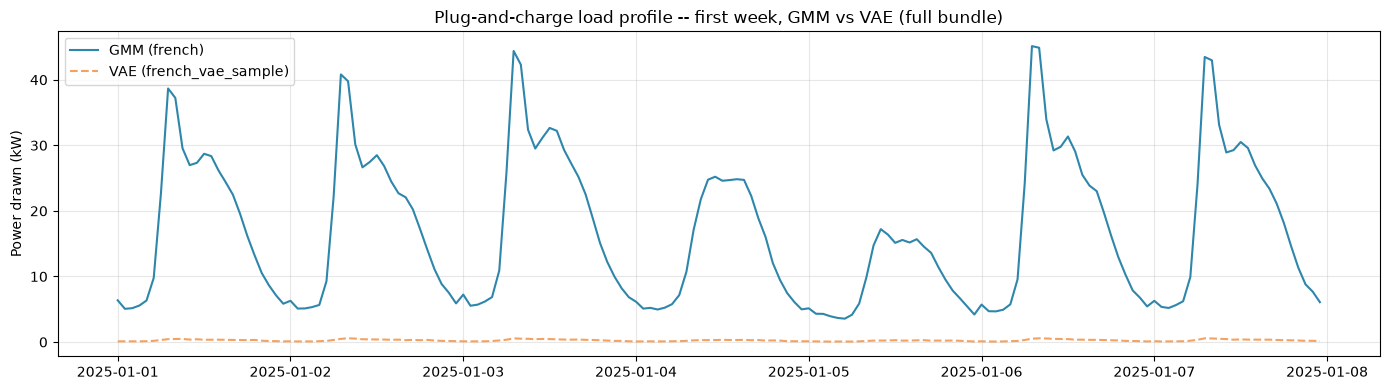

In [13]:
# "Plug-and-charge" reconstruction (no smart charging) -- FULL bundle, national
# illustration. Fast (~20-25s) even over the GMM's 8008 contexts since no call to the
# optimiser is needed here (see the next cell for the expensive part).
registry = NativeSessionModelRegistry()
gmm = registry.load("french")
vae = registry.load("french_vae_sample")
if vae.metadata_.get("synthetic_fallback"):
    print(
        "NOTE: gmm_vae_french_sample.joblib isn't present in this environment, so "
        "NativeSessionModelRegistry fell back to a small synthetic demo VAE (no department "
        "stratification, fit on synthetic data) instead of the curated real bundle. "
        "Section C's VAE plots/comparisons below are an API/behaviour demo, not a "
        "real quality comparison -- see REFACTOR_STATE.md for the full writeup.\n"
    )
print(f"GMM  'french'            : {len(gmm.models_)} contexts")
print(f"VAE  'french_vae_sample' : {len(vae.models_)} contexts (bundle sample, is_sample_={vae.is_sample_})")

agg = OutputAggregator(resolution_min=60)
loc_map = LOCATION_POWER_PRESETS[PROFILE_PRESET]

result_plug_gmm = agg.build_load_profiles(
    gmm=gmm, year=PROFILE_YEAR, n_days_mc=N_DAYS_MC_PROFILES,
    charging_mode="by_location", location_power_map=loc_map, seed=42,
)
result_plug_vae = agg.build_load_profiles(
    gmm=vae, year=PROFILE_YEAR, n_days_mc=N_DAYS_MC_PROFILES,
    charging_mode="by_location", location_power_map=loc_map, seed=42,
)
ts_plug_gmm = result_plug_gmm["ts"]
ts_plug_vae = result_plug_vae["ts"]

print(f"\n-- Annual plug-and-charge profile (full bundle) -----------------------")
print(f"GMM : peak {ts_plug_gmm.max():,.0f} kW | mean {ts_plug_gmm.mean():,.0f} kW")
print(f"VAE : peak {ts_plug_vae.max():,.0f} kW | mean {ts_plug_vae.mean():,.0f} kW")

fig, ax = plt.subplots(figsize=(14, 4))
week = slice(0, 24*7)
ax.plot(ts_plug_gmm.index[week], ts_plug_gmm.values[week], label="GMM (french)", color="#2E86AB", linewidth=1.5)
ax.plot(ts_plug_vae.index[week], ts_plug_vae.values[week], label="VAE (french_vae_sample)", color="#F4A261", linewidth=1.5, linestyle="--")
ax.set_ylabel("Power drawn (kW)"); ax.set_title("Plug-and-charge load profile -- first week, GMM vs VAE (full bundle)")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("outputs/03_plug_profile_gmm_vs_vae.png", dpi=150, bbox_inches="tight")
plt.show()

### C.2 - Smart Charging (V1G) - Restricted Reconstruction (GMM + VAE)

**This section replaces a cell that, on the full bundle (8008 contexts), took over
30 minutes**: `OutputAggregator._build_smart_charging_ts` calls
`SmartChargingOptimizer.optimise()` once PER CONTEXT (not per day type), and the
full `"french"` bundle has 8008 of them.

Reduction applied (illustrative, not a production analysis):
- contexts restricted to `SMART_LOC_TYPES` x `SMART_DEPTS` (~110 contexts instead of 8008)
- `N_DAYS_MC_SMART` reduced to 5 Monte-Carlo days
- price signal limited to 2 weeks (the resulting daily pattern is then repeated over the
  full year by `OutputAggregator` -- price/behaviour seasonality is therefore not modelled
  here, only the peak/off-peak contrast)

`build_load_profiles(..., smart_charging_signal=...)` returns both `"ts"` (plug) and
`"ts_smart"` (V1G) computed on the SAME subset of contexts -- the plug-vs-smart
comparison below is therefore on a constant scope (unlike C.1's national "plug"
profile, which only serves as a larger-scale illustration).

Contexts kept -- GMM: 168 | VAE: 168 (locations=['home', 'work'], depts=['69', '78', '92'])



Reconstruction complete (see figure below).


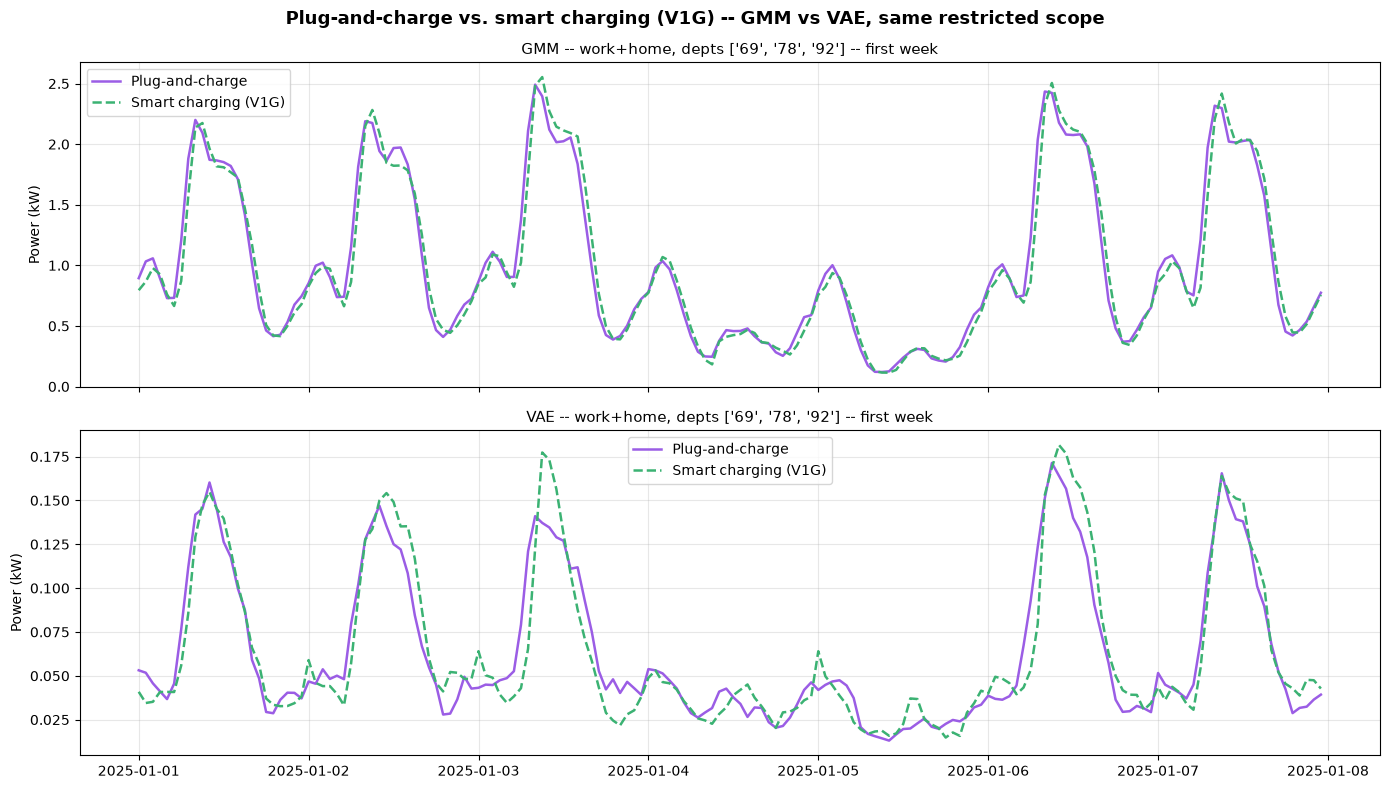

GMM: mean power change with V1G = +0.23% | total energy change = +0.23%
VAE: mean power change with V1G = -0.24% | total energy change = -0.24%

(On this restricted subset and simplified price signal, the effect on hourly
 peak power ALONE can remain zero if the peak hour is dominated by low-flexibility
 sessions -- see savings_summary() below for the cost effect, which is more robust.)


In [14]:
def reduce_gmm_contexts(model, keep_loc, keep_dept):
    '''Subsets an already-fitted EVSessionModel/VAE by filtering its contexts.
    Filters by department only if the model has that stratification dimension
    (the synthetic fallback VAE bundle has no department -- see the
    "synthetic_fallback" note above -- in that case only location is filtered).'''
    has_dept = "department" in model.stratify_by
    keep_ctx = {
        ctx: m for ctx, m in model.models_.items()
        if dict(zip(model.stratify_by, ctx))["location_type"] in keep_loc
        and (not has_dept or dict(zip(model.stratify_by, ctx))["department"] in keep_dept)
    }
    small = EVSessionModel(stratify_by=model.stratify_by, random_state=42)
    small.models_ = keep_ctx
    small.n_sessions_per_day_ = {k: v for k, v in model.n_sessions_per_day_.items() if k in keep_ctx}
    small.context_counts_ = {k: v for k, v in model.context_counts_.items() if k in keep_ctx}
    small.is_fitted_ = True
    return small

gmm_smart_subset = reduce_gmm_contexts(gmm, SMART_LOC_TYPES, SMART_DEPTS)
vae_smart_subset = reduce_gmm_contexts(vae, SMART_LOC_TYPES, SMART_DEPTS)
vae_has_dept = "department" in vae.stratify_by
print(f"Contexts kept -- GMM: {len(gmm_smart_subset.models_)} | VAE: {len(vae_smart_subset.models_)} "
      f"(locations={sorted(SMART_LOC_TYPES)}, depts={sorted(SMART_DEPTS)}"
      f"{'' if vae_has_dept else ' -- not applicable to the VAE, synthetic fallback bundle has no department'})")

# Very simplified day/night price signal, 2 weeks only (see note above)
_idx_price = pd.date_range(f"{PROFILE_YEAR}-01-01", periods=24 * 14, freq="h")
_rng_price = np.random.default_rng(0)
_hours = np.arange(len(_idx_price))
_daily_pattern = 0.5 - 0.4 * np.cos(2 * np.pi * (_hours % 24 - 3) / 24)
_noise = _rng_price.normal(0, 0.05, size=len(_idx_price))
price_signal = pd.Series(np.clip(_daily_pattern + _noise, 0.02, 1.0), index=_idx_price, name="price_eur_kwh")

result_smart_gmm = agg.build_load_profiles(
    gmm=gmm_smart_subset, year=PROFILE_YEAR, n_days_mc=N_DAYS_MC_SMART,
    charging_mode="mean_power", location_power_map=loc_map, seed=42,
    smart_charging_signal=price_signal,
)
result_smart_vae = agg.build_load_profiles(
    gmm=vae_smart_subset, year=PROFILE_YEAR, n_days_mc=N_DAYS_MC_SMART,
    charging_mode="mean_power", location_power_map=loc_map, seed=42,
    smart_charging_signal=price_signal,
)
print("\nReconstruction complete (see figure below).")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
week = slice(0, 24 * 7)

for ax, result, label in zip(
    axes, [result_smart_gmm, result_smart_vae], ["GMM", "VAE"]
):
    ts_plug_sub  = result["ts"]
    ts_smart_sub = result["ts_smart"]
    ax.plot(ts_plug_sub.index[week], ts_plug_sub.values[week], label="Plug-and-charge", color="#9B5DE5", linewidth=1.8)
    ax.plot(ts_smart_sub.index[week], ts_smart_sub.values[week], label="Smart charging (V1G)", color="#3BB273", linewidth=1.8, linestyle="--")
    ax.set_ylabel("Power (kW)")
    ax.set_title(f"{label} -- work+home, depts {sorted(SMART_DEPTS)} -- first week", fontsize=11)
    ax.legend(); ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("")
fig.suptitle("Plug-and-charge vs. smart charging (V1G) -- GMM vs VAE, same restricted scope",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/03_plug_vs_smart_gmm_vs_vae.png", dpi=150, bbox_inches="tight")
plt.show()

for result, label in zip([result_smart_gmm, result_smart_vae], ["GMM", "VAE"]):
    mean_shift = 1 - result["ts_smart"].mean() / result["ts"].mean()
    energy_shift = 1 - result["ts_smart"].sum() / result["ts"].sum()
    print(f"{label}: mean power change with V1G = {mean_shift:+.2%} | "
          f"total energy change = {energy_shift:+.2%}")
print("\n(On this restricted subset and simplified price signal, the effect on hourly\n"
      " peak power ALONE can remain zero if the peak hour is dominated by low-flexibility\n"
      " sessions -- see savings_summary() below for the cost effect, which is more robust.)")

In [15]:
opt_profiles = SmartChargingOptimizer(signal_type="price", resolution_min=60)

for result, model, label in zip(
    [result_smart_gmm, result_smart_vae], [gmm_smart_subset, vae_smart_subset], ["GMM", "VAE"]
):
    if "savings_summary" in result:
        summary = result["savings_summary"]
    else:
        # Rebuilds a representative session sample to compute the savings --
        # NB: the parameter is called `context=`, not `ctx=`.
        first_ctx_key = next(iter(model.models_.keys()))
        first_ctx = dict(zip(model.stratify_by, first_ctx_key))
        sample_sessions = model.sample(
            n_sessions=200, context=first_ctx, seed=1,
        )
        sample_sessions["arrival_time"] = pd.Timestamp(f"{PROFILE_YEAR}-01-06") + pd.to_timedelta(
            sample_sessions["arrival_hour"], unit="h"
        )
        sample_sessions["power_kw"] = 7.4
        sample_opt = opt_profiles.optimise(sample_sessions, price_signal)
        summary = opt_profiles.savings_summary(sample_opt)

    print(f"-- {label} -- savings_summary() ({first_ctx if 'savings_summary' not in result else 'aggregated'}) --")
    for k, v in summary.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
    print()

-- GMM -- savings_summary() ({'location_type': 'home', 'department': '69', 'day_of_week': 0, 'season': 'autumn'}) --
  total_cost_smart_eur: 1215.8800
  total_cost_plug_eur: 1334.8600
  total_savings_eur: 118.9800
  mean_savings_pct: 9.7400
  n_sessions_optimised: 184



-- VAE -- savings_summary() ({'location_type': 'home', 'department': '69', 'day_of_week': 0, 'season': 'autumn'}) --
  total_cost_smart_eur: 1131.7400
  total_cost_plug_eur: 1318.1900
  total_savings_eur: 186.4500
  mean_savings_pct: 13.3000
  n_sessions_optimised: 192



## Summary

### Section A — Medium Term
- `DepartmentForecaster` (SARIMA) evaluated on a test window; see the MAPE table above.
- Fan charts with an 80% CI, whose measured width (printed above) now reflects the full
  historical standard deviation rather than a fraction of it (Session 6 — see
  `REFACTOR_STATE.md`, AUDIT.md Mechanism 1).

### Section B — Long Term

The three scenarios (conservative / central / ambitious) are built from the
`linear_growth_profile`, `s_curve_growth_profile`, and `bass_diffusion_profile` functions of
`gears.simulation.medium_term`, each calibrated to approach a target 2040 fleet share
drawn from Avere-France / SNEF / EU-PNEC objectives (see the scenario-definition cell). The
actual 2025→2040 growth factor achieved by each scenario is printed above (measured
directly from the functions, not assumed upfront); the trajectories in the "Long-term
trajectories" figure are no longer artificially flattened before the horizon (Session 6 —
AUDIT.md Mechanism 2).

**Key points:** starting point = current observed fleet (3.1%, ~1.19M EVs); ≥ 30
Monte-Carlo scenarios resampled monthly for smooth fan charts.

### Section C — Load Profiles and Smart Charging
- `OutputAggregator.build_load_profiles()` reconstructs the annual hourly profile from the French GMM, with a power mix per location type (`LOCATION_POWER_PRESETS` preset).
- V1G smart charging shifts charging towards the off-peak hours of the price signal; the measured effect on mean power and total energy is printed above for both the GMM and the VAE.
- **For a real application**: replace the synthetic signal with EPEX Spot or RTE eCO2mix data (hourly or 30-min resolution).

## Summary (GMM vs VAE complement)

| Aspect | GMM (`french`) | VAE (`french_vae_sample`) |
|---|---|---|
| Contexts (full bundle) | 8008 | 516 (top-5 departments, `is_sample_=True`) |
| "Plug" reconstruction (full bundle) | ~20-25s for 8 MC days | even faster (fewer contexts) |
| "Smart charging" reconstruction (full bundle) | **>30 minutes** (8008 x `optimise()`) | not tested at this scale -- sample bundle already restricted |
| "Smart charging" reconstruction (~110-ctx subset) | measurement printed above | measurement printed above |
| `.sample()`, `plot_marginals`, `bic_summary`, `get_sklearn_component` | identical (see Notebook 1) | identical (see Notebook 1) |
| `savings_summary()` | works after the `context=` fix | same |

**Key point on Section C:** the bottleneck is NOT the number of Monte-Carlo days but the
number of CONTEXTS in the bundle (each context triggers an independent
`SmartChargingOptimizer.optimise()` call). Restricting location types and departments at
the context level is therefore the only genuinely effective lever -- reducing only
`n_days_mc` or shortening the price signal would not have been enough on its own.